In [1]:
import torch
print(torch.cuda.is_available())
print(torch.__version__)

True
2.5.1


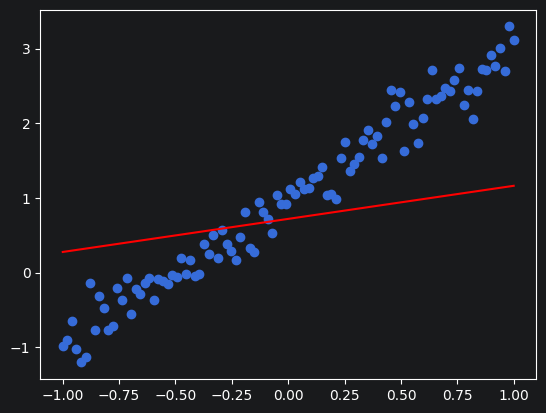

In [4]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ---------- 1. 生成“假”数据 ----------
# 在 -1 到 1 之间生成 100 个点，并变成列向量
x = torch.linspace(-1, 1, 100).reshape(-1, 1)
# 构造一条直线 y = 2x + 1，并加上一点随机噪声，让数据更真实
y = 2 * x + 1 + 0.2 * torch.randn(x.size())

# ---------- 2. 创建一个最简单的神经网络（线性模型） ----------
# 这相当于一个 y = wx + b 的模型，w 和 b 是待学习的参数
model = nn.Linear(1, 1)
# 定义优化器（SGD，即随机梯度下降），学习率设为 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
# 定义损失函数（均方误差，MSE），用来衡量预测值与真实值的差距
loss_func = nn.MSELoss()

# ---------- 3. 训练模型 ----------
# 让模型“看”数据 50 次（50 轮迭代）
for step in range(50):
    # 用当前模型预测 x 对应的 y_pred
    pred = model(x)
    # 计算预测值与真实值之间的损失
    loss = loss_func(pred, y)

    # 这三行是 PyTorch 的标准训练模板：
    optimizer.zero_grad()   # 清空上一步的梯度
    loss.backward()         # 反向传播，计算梯度
    optimizer.step()        # 根据梯度更新模型参数 (w 和 b)

# ---------- 4. 画图查看结果 ----------
# 绘制原始数据点（蓝色散点）
plt.scatter(x.numpy(), y.numpy())
# 绘制模型学习到的直线（红色）
plt.plot(x.numpy(), model(x).detach().numpy(), 'r-')
# 保存图片到当前工作目录，文件名为 figure.png
plt.savefig('figure.png')
# 显示图表
plt.show()